In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/sample_data/customer_shopping_behavior git.csv")
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


**BASIC EXPLORATION**

In [ ]:
df.shape
print("---------------")
df.info()


---------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         

In [ ]:
#checking for nulls
df.isnull().sum()


,0
Customer ID,0
Age,0
Gender,0
Item Purchased,0
Category,0
Purchase Amount (USD),0
Location,0
Size,0
Color,0
Season,0


In [ ]:
# Summary statistics using .describe()
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3863.000000,3900,3900,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,6,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,Free Shipping,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,675,2223,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.750065,NaN,NaN,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716983,NaN,NaN,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.800000,NaN,NaN,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,NaN,NaN,38.000000,NaN,NaN


In [ ]:
df.columns

Index(['Customer ID', 'Age', 'Gender', 'Item Purchased', 'Category',
       'Purchase Amount (USD)', 'Location', 'Size', 'Color', 'Season',
       'Review Rating', 'Subscription Status', 'Shipping Type',
       'Discount Applied', 'Promo Code Used', 'Previous Purchases',
       'Payment Method', 'Frequency of Purchases'],
      dtype='object')

**DATA CLEANING**

In [ ]:
# Renaming columns according to snake casing for better readability and documentation

df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_')
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [ ]:
#checking for duplicates
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
#Unique Value Analysis
df.nunique()

,0
customer_id,3900
age,53
gender,2
item_purchased,25
category,4
purchase_amount,81
location,50
size,4
color,25
season,4


In [ ]:
'''
Insight:
- The dataset looks clean with no missing or duplicate values
- This means we can trust the analysis without worrying about data quality issues
'''

DEMOGRAPHIC ANALYSIS

/tmp/ipykernel_709/2300232212.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gender", data=df, palette="Set2")


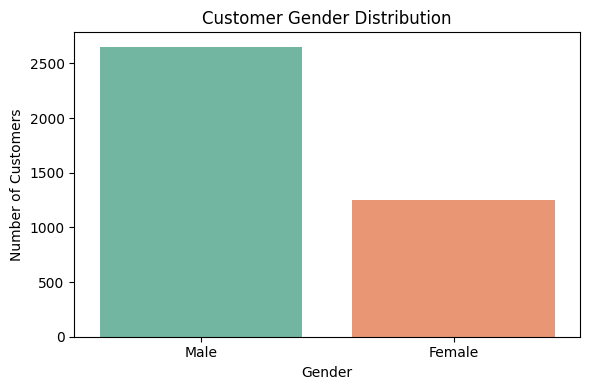

In [ ]:
#age Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="gender", data=df, palette="Set2")
plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [ ]:
'''
Insight:
- Most customers fall in the young to middle-age group
- This suggests the platform mainly attracts active working-age users
'''

/tmp/ipykernel_709/1381267122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="gender", data=df, palette="Set2")


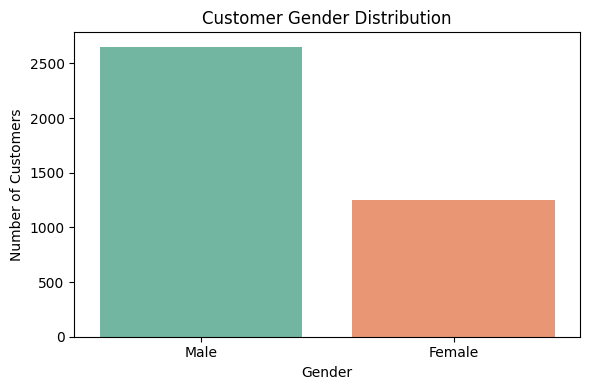

In [ ]:
#Gender Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="gender", data=df, palette="Set2")
plt.title("Customer Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

In [ ]:
'''
Insight:
- Customer distribution is fairly balanced between genders (or slightly dominated by one group)
- This means marketing can be either general or slightly targeted depending on dominance
'''

**PURCHASE AMOUNT ANALYSIS**

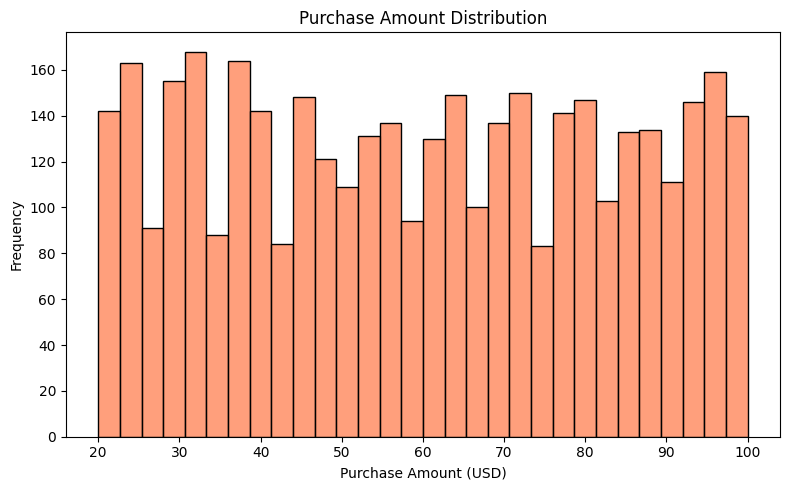

In [ ]:
#Overall Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df["purchase_amount"], bins=30, color='coral')
plt.title("Purchase Amount Distribution")
plt.xlabel("Purchase Amount (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

/tmp/ipykernel_709/11439680.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='category', y='purchase_amount', data=df, palette='pastel')


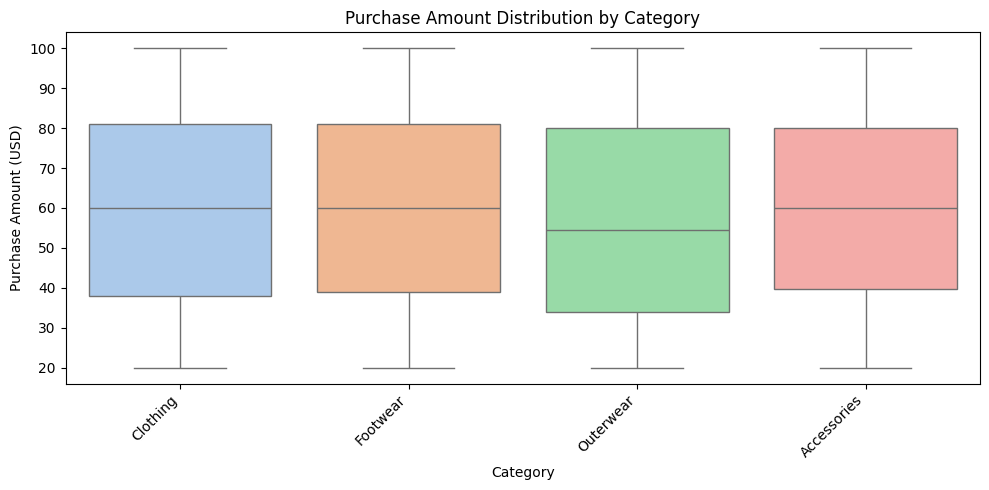

In [ ]:
#Spend Distribution by Category
plt.figure(figsize=(10, 5))
sns.boxplot(x='category', y='purchase_amount', data=df, palette='pastel')
plt.title("Purchase Amount Distribution by Category")
plt.xlabel("Category")
plt.ylabel("Purchase Amount (USD)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**CATEGORY AND ITEM ANALYSIS**


Top 10 Purchased Items:
item_purchased
Blouse        171
Pants         171
Jewelry       171
Shirt         169
Dress         166
Sweater       164
Jacket        163
Coat          161
Sunglasses    161
Belt          161
Name: count, dtype: int64


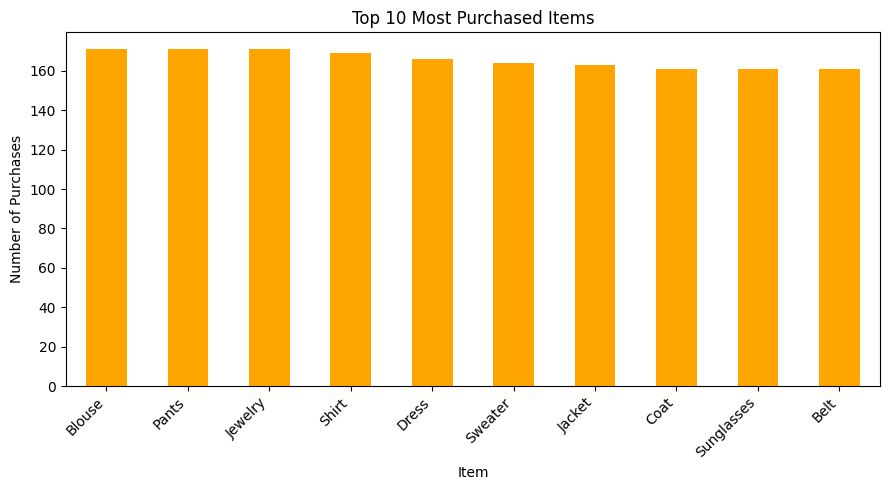

In [ ]:
#Top 10 Purchased Items
top_items = df["item_purchased"].value_counts().head(10)
print("\nTop 10 Purchased Items:")
print(top_items)

plt.figure(figsize=(9, 5))
top_items.plot(kind="bar", color='orange')
plt.title("Top 10 Most Purchased Items")
plt.xlabel("Item")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Revenue by Category:
category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount, dtype: int64


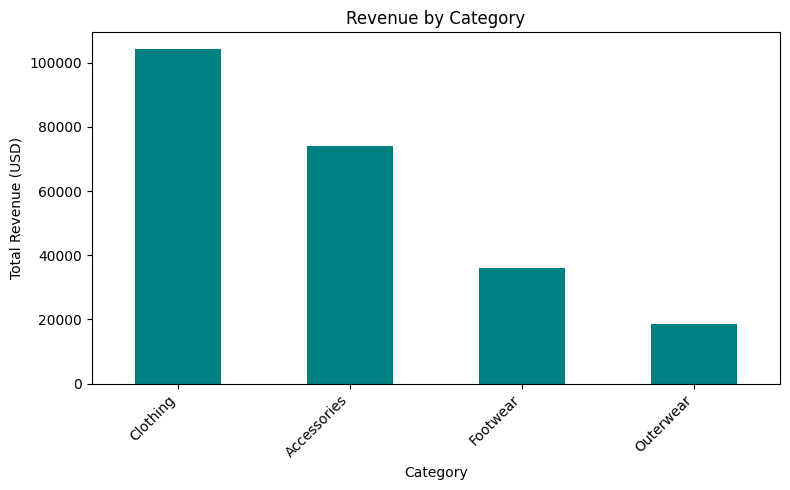

In [ ]:
#Revenue by Category
category_sales = df.groupby("category")["purchase_amount"].sum().sort_values(ascending=False)
print("\nRevenue by Category:")
print(category_sales)

plt.figure(figsize=(8, 5))
category_sales.plot(kind="bar", color='teal')
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Item count by Category:
category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: item_purchased, dtype: int64


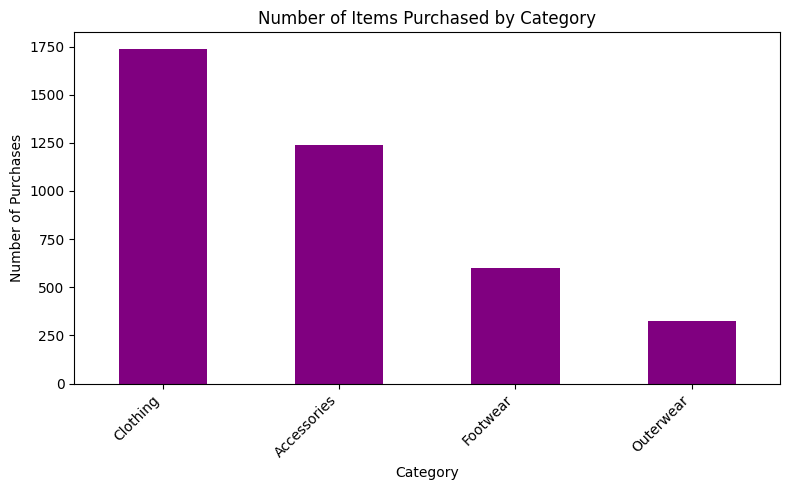

In [ ]:
#Item Purchases by Category
category_item_counts = df.groupby('category')['item_purchased'].count().sort_values(ascending=False)
print("\nItem count by Category:")
print(category_item_counts)

plt.figure(figsize=(8, 5))
category_item_counts.plot(kind='bar', color='purple')
plt.title("Number of Items Purchased by Category")
plt.xlabel("Category")
plt.ylabel("Number of Purchases")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**REVENUE BREAKDOWNS**


Revenue by Gender:
gender
Female     75191
Male      157890
Name: purchase_amount, dtype: int64


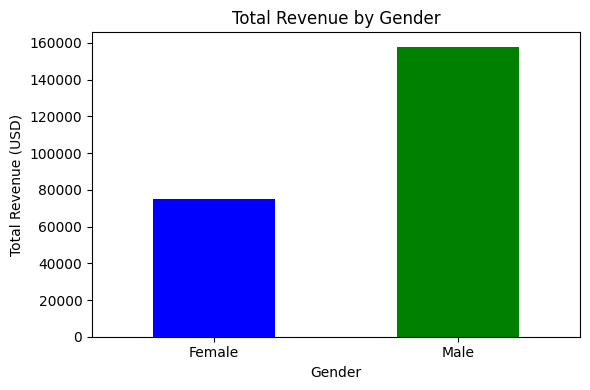

In [ ]:
#Revenue by Gender
gender_revenue = df.groupby("gender")["purchase_amount"].sum()
print("\nRevenue by Gender:")
print(gender_revenue)

plt.figure(figsize=(6, 4))
gender_revenue.plot(kind="bar", color=['blue','green'])
plt.title("Total Revenue by Gender")
plt.xlabel("Gender")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
'''
Males spent $157890 — that's 67.7% of total revenue
Females spent $75191 — only 32.3%
But average spend per visit is almost equal (~$60 each)
The gap is because there are 2652 male customers vs only 1248 female customers in the data
'''


Revenue by Season:
season
Fall      60018
Spring    58679
Winter    58607
Summer    55777
Name: purchase_amount, dtype: int64


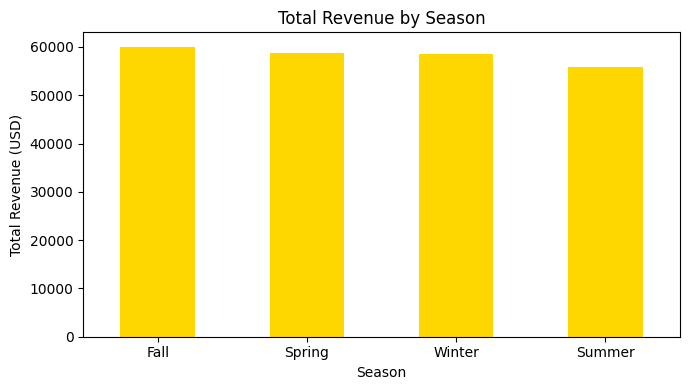

In [ ]:
#Revenue by Season
season_revenue = df.groupby("season")["purchase_amount"].sum().sort_values(ascending=False)
print("\nRevenue by Season:")
print(season_revenue)

plt.figure(figsize=(7, 4))
season_revenue.plot(kind="bar", color='gold')
plt.title("Total Revenue by Season")
plt.xlabel("Season")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
'''
Fall = $60018 — highest
Spring = $58679 — second
Winter = $58607 — third
Summer = $55777 — lowest
Gap between best and worst = only $4241 — all seasons are very close
'''

**PAYMENT METHOD ANALYSIS**


Payment Method Counts:
payment_method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64


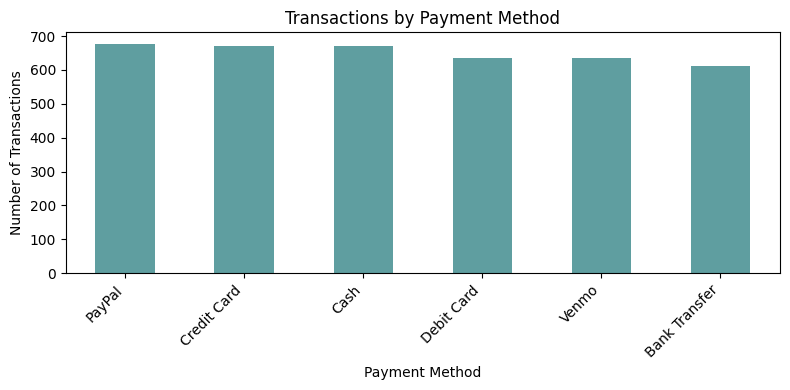

In [ ]:
#Payment Method Frequency
payment_sales = df["payment_method"].value_counts()
print("\nPayment Method Counts:")
print(payment_sales)

plt.figure(figsize=(8, 4))
payment_sales.plot(kind="bar", color='cadetblue')
plt.title("Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Average Purchase by Payment Method:
payment_method
Debit Card       60.915094
Credit Card      60.074516
Bank Transfer    59.712418
Cash             59.704478
PayPal           59.245199
Venmo            58.949527
Name: purchase_amount, dtype: float64


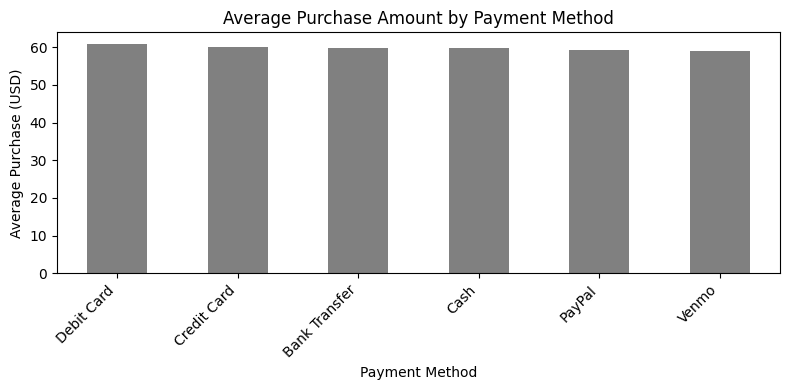

In [ ]:
#Average Spend by Payment Method
payment_behavior = df.groupby('payment_method')['purchase_amount'].mean().sort_values(ascending=False)
print("\nAverage Purchase by Payment Method:")
print(payment_behavior)

plt.figure(figsize=(8, 4))
payment_behavior.plot(kind='bar', color='gray')
plt.title("Average Purchase Amount by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Purchase (USD)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
'''
overall
Credit Card brings the most total revenue — $40310
Bank Transfer brings the least — $36544
BUT average order value is nearly the same across all methods
Debit Card has the highest average order value — $60.91 per transaction
Venmo has the lowest — $58.95 per transaction
'''

CORRELATION ANALYSIS

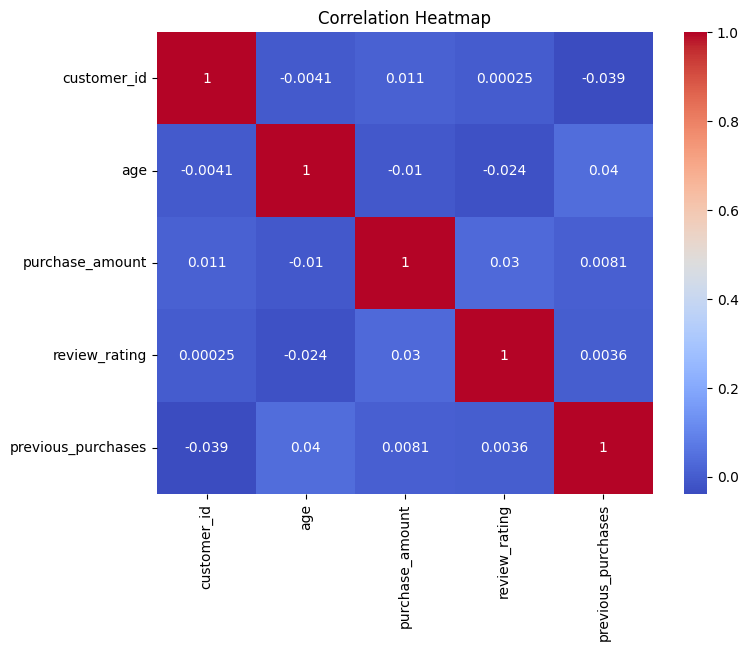

In [ ]:
#Correlation Analysis
import numpy as np
numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# **KPIs (Key Performance Indicators)**


Average Order Value per Category:
category
Footwear       60.255426
Clothing       60.025331
Accessories    59.838710
Outerwear      57.172840
Name: purchase_amount, dtype: float64


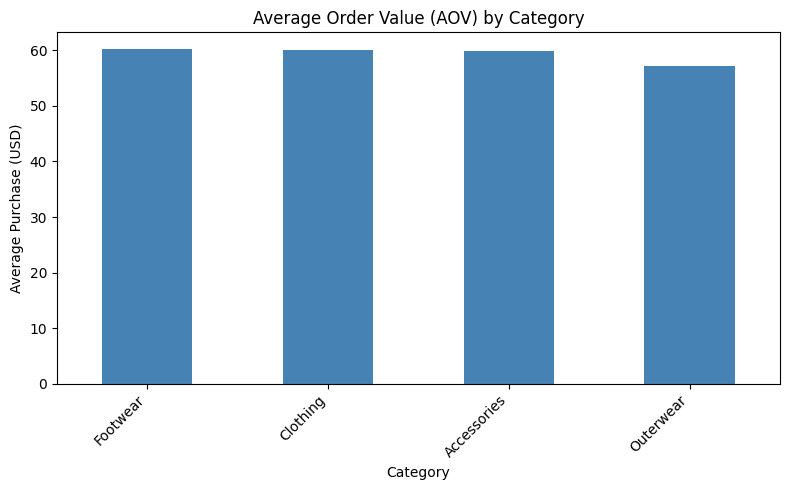

In [ ]:
####Calculate all KPIs

# Total money earned across all transactions
total_revenue = df['purchase_amount'].sum()

# Total number of transactions (rows in the dataset)
total_transactions = len(df)

# Average amount per transaction (total ÷ count)
avg_order_value = df['purchase_amount'].mean()

# Middle value — 50% of orders are above this, 50% below
median_order_value = df['purchase_amount'].median()

# Category with the highest total revenue (.idxmax() returns the name, not the number)
top_category = df.groupby('category')['purchase_amount'].sum().idxmax()

# Season with the highest total revenue
top_season = df.groupby('season')['purchase_amount'].sum().idxmax()

# Payment method with the highest total revenue
top_payment = df.groupby('payment_method')['purchase_amount'].sum().idxmax()

# Top 10% spender threshold — what amount puts you in the top 10%?
top10_threshold = df['purchase_amount'].quantile(0.90)

# Count how many customers are at or above that threshold
top10_count = (df['purchase_amount'] >= top10_threshold).sum()

# What % of all customers are top-10% spenders?
top10_pct = (top10_count / total_transactions) * 100

# Average spend per transaction, broken down by category
aov_by_category = df.groupby('category')['purchase_amount'].mean().sort_values(ascending=False)

print("\nAverage Order Value per Category:")
print(aov_by_category)

plt.figure(figsize=(8, 5))
aov_by_category.plot(kind='bar', color='steelblue')
plt.title("Average Order Value (AOV) by Category")
plt.xlabel("Category")
plt.ylabel("Average Purchase (USD)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


**Top Category Contribution**

Revenue per Category:
category
Clothing       104264
Accessories     74200
Footwear        36093
Outerwear       18524
Name: purchase_amount, dtype: int64
------------------------------

% Revenue Contribution per Category:
category
Clothing       44.73
Accessories    31.83
Footwear       15.49
Outerwear       7.95
Name: purchase_amount, dtype: float64
------------------------------


([0, 1, 2, 3],
 [Text(0, 0, 'Clothing'),
  Text(1, 0, 'Accessories'),
  Text(2, 0, 'Footwear'),
  Text(3, 0, 'Outerwear')])

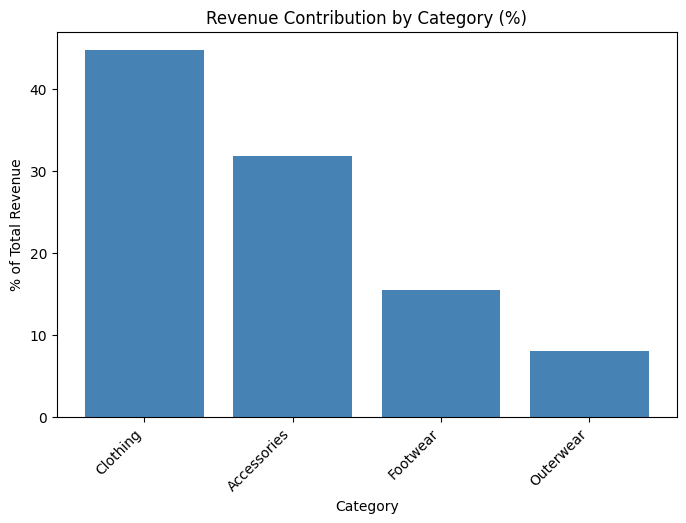

In [ ]:
# Group all rows by category, then add up the purchase_amount for each
category_revenue = df.groupby('category')['purchase_amount'].sum()

# Sort from highest to lowest so the most important appears first
category_revenue = category_revenue.sort_values(ascending=False)

print("Revenue per Category:")
print(category_revenue)
print("------------------------------")

#Convert to percentage
total_revenue = df['purchase_amount'].sum()
category_pct  = (category_revenue / total_revenue * 100).round(2)
print("\n% Revenue Contribution per Category:")
print(category_pct)
print("------------------------------")
#barchat
plt.figure(figsize=(8, 5))
bars = plt.bar(category_pct.index, category_pct.values, color='steelblue')
plt.title("Revenue Contribution by Category (%)")
plt.xlabel("Category")
plt.ylabel("% of Total Revenue")
plt.xticks(rotation=45, ha='right')

In [ ]:
'''
-Nearly half of all revenue comes from just Clothing alone
-Clothing + Accessories together = 76.5% — the business basically runs on these two categories
-Footwear and Outerwear together bring in only 23.5% — they are being ignored by customers
-Outerwear at 7.9% is extremely low — only 324 people bought from it out of 3900 customers
'''

Payment method performance



How many times each payment method was used:
payment_method
PayPal           677
Credit Card      671
Cash             670
Debit Card       636
Venmo            634
Bank Transfer    612
Name: count, dtype: int64
---------------------------

Total Revenue per Payment Method:
payment_method
Credit Card      40310
PayPal           40109
Cash             40002
Debit Card       38742
Venmo            37374
Bank Transfer    36544
Name: purchase_amount, dtype: int64
---------------------------

Average Order Value per Payment Method:
payment_method
Debit Card       60.915094
Credit Card      60.074516
Bank Transfer    59.712418
Cash             59.704478
PayPal           59.245199
Venmo            58.949527
Name: purchase_amount, dtype: float64
---------------------------


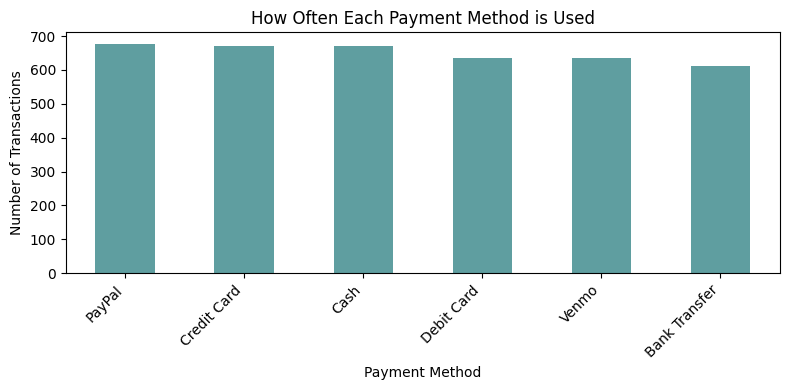

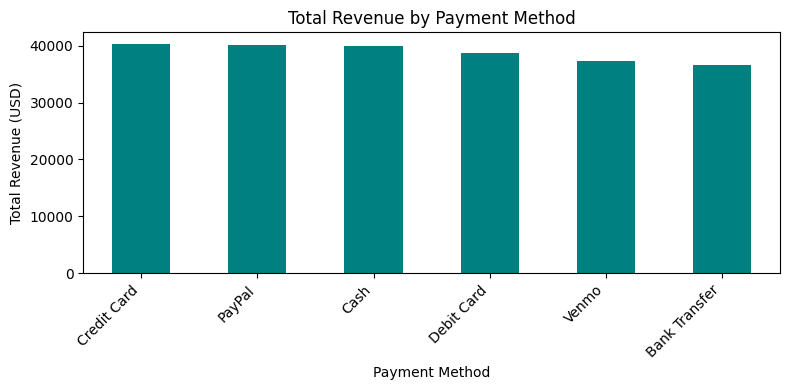

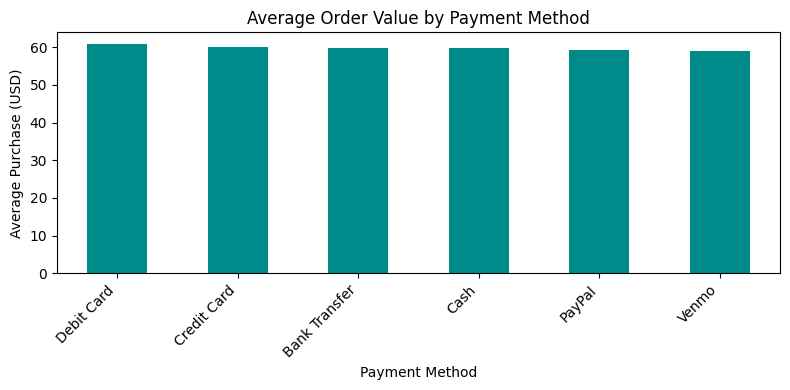

In [ ]:
#Count how many times each payment method was used
payment_count = df['payment_method'].value_counts()
print("How many times each payment method was used:")
print(payment_count)
print("---------------------------")

#Total revenue per payment method
payment_revenue = df.groupby('payment_method')['purchase_amount'].sum().sort_values(ascending=False)
print("\nTotal Revenue per Payment Method:")
print(payment_revenue)
print("---------------------------")

#Average order value per payment method
payment_avg = df.groupby('payment_method')['purchase_amount'].mean().sort_values(ascending=False)
print("\nAverage Order Value per Payment Method:")
print(payment_avg)
print("---------------------------")

#comparison of 3 plots
#1
plt.figure(figsize=(8, 4))
payment_count.plot(kind='bar', color='cadetblue')
plt.title("How Often Each Payment Method is Used")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
#2
plt.figure(figsize=(8, 4))
payment_revenue.plot(kind='bar', color='teal')
plt.title("Total Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue (USD)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
#3
plt.figure(figsize=(8, 4))
payment_avg.plot(kind='bar', color='darkcyan')
plt.title("Average Order Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Average Purchase (USD)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
'''
Credit Card made the most money — $40310
Bank Transfer made the least — $36544
Debit Card customers spend the most per order — $60.91
Venmo customers spend the least per order — $58.95
'''

# Cohort Thinking

/tmp/ipykernel_709/3911846842.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_spend = df.groupby(['age_group', 'gender'])['purchase_amount'].mean().unstack()



Average Spend by Age Group & Gender:
gender        Female       Male
age_group                      
18-24      60.394737  60.113772
25-34      62.128631  59.196498
35-44      59.258621  59.788732
45-54      58.968504  61.028112
55-64      60.596708  57.816929
65-70      60.365385  60.179688


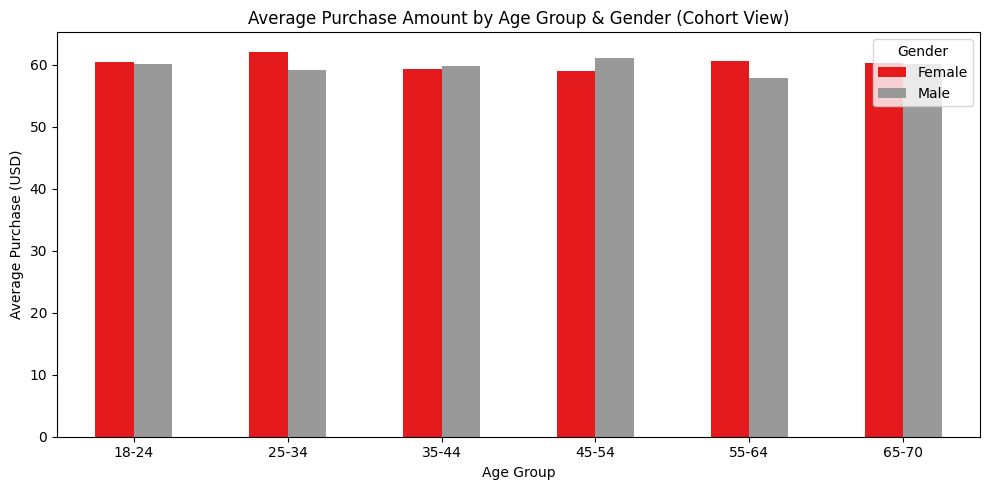

In [ ]:
# Create age groups
bins = [18, 25, 35, 45, 55, 65, 70]
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65-70']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

#Average Spend per Cohort
cohort_spend = df.groupby(['age_group', 'gender'])['purchase_amount'].mean().unstack()
print("\nAverage Spend by Age Group & Gender:")
print(cohort_spend)
cohort_spend.plot(kind='bar', figsize=(10, 5), colormap='Set1')
plt.title("Average Purchase Amount by Age Group & Gender (Cohort View)")
plt.xlabel("Age Group")
plt.ylabel("Average Purchase (USD)")
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

In [ ]:
'''
->25-34 females spend the most at $62.13 — they are the highest spending group in the whole dataset
->55-64 males spend the least at $57.82 — the lowest in the whole dataset
->Females spend more than males in 18-24, 25-34, 55-64 and 65-70 age groups
->Males spend more than females only in 35-44 and 45-54 age groups
'''

/tmp/ipykernel_709/3607419908.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cohort_category = df.groupby(['age_group', 'category'])['purchase_amount'].sum().unstack(fill_value=0)


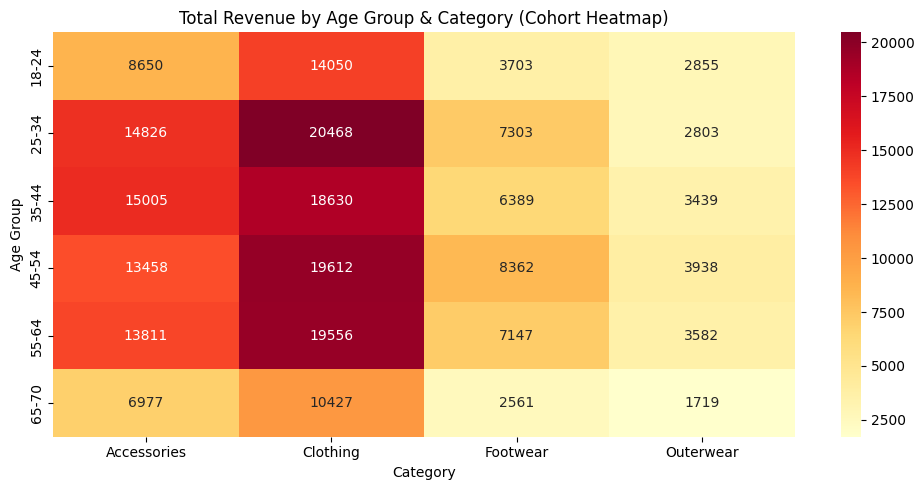

In [ ]:
#Category Preference Heatmap by Age Group
cohort_category = df.groupby(['age_group', 'category'])['purchase_amount'].sum().unstack(fill_value=0)
plt.figure(figsize=(10, 5))
sns.heatmap(cohort_category, annot=True, fmt='.0f', cmap='YlOrRd')
plt.title("Total Revenue by Age Group & Category (Cohort Heatmap)")
plt.xlabel("Category")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()

In [ ]:
'''
->25-34 and 35-44 are the biggest spending age groups overall
->The older the customer (65-70), the less they spend across all categories — simply because there are fewer of them
->Outerwear is ignored by every age group — it's not just one age group avoiding it, everyone is
'''